# Reuters C50 - Klasifikacija autora novinskih tekstova
## 04 - TF-IDF vektorizacija i klasifikacija

Treniramo **7 klasifikatora** na **3 skupa atributa** (10 000 / 2 000 / 500 TF-IDF features).
Ukupno: 21 model. Svaki model se evaluira na test skupu koji nije viđen tokom treniranja.

### Ćelija 1 - Uvoz biblioteka i učitavanje podataka

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

SLIKE_PATH   = '/home/zagorka/Desktop/ip2Projekat/slike'
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('/home/zagorka/Desktop/ip2Projekat/reuters_preprocessed.csv')
train_df = df[df['split'] == 'C50train'].reset_index(drop=True)
test_df  = df[df['split'] == 'C50test'].reset_index(drop=True)

X_train_raw = train_df['text_clean']
X_test_raw  = test_df['text_clean']
y_train     = train_df['author']
y_test      = test_df['author']

print(f'Train: {len(X_train_raw)} | Test: {len(X_test_raw)}')
print(f'Klase: {y_train.nunique()}') 

Train: 2500 | Test: 2500
Klase: 50


> **Zaključak:** Preprocesirani podaci su uspešno učitani i podeljeni na train (2500 dok.) i test (2500 dok.) skup. Koristimo originalne split oznake iz dataseta, čime je garantovano da nijedan test dokument nije viđen tokom treniranja. Ciljni atribut je `author` — 50 klasa, savršeno balansiranih.

### Ćelija 2 - TF-IDF vektorizacija (3 skupa atributa)

In [3]:
# Puni skup: 10 000 unigramma i bigramma
tfidf_full = TfidfVectorizer(max_features=10000, ngram_range=(1,2), sublinear_tf=True)
X_train_full = tfidf_full.fit_transform(X_train_raw)
X_test_full  = tfidf_full.transform(X_test_raw)

# Redukovani skup: 2 000 unigramma
tfidf_red = TfidfVectorizer(max_features=2000, ngram_range=(1,1), sublinear_tf=True)
X_train_red = tfidf_red.fit_transform(X_train_raw)
X_test_red  = tfidf_red.transform(X_test_raw)

# Mali skup: 500 unigramma
tfidf_small = TfidfVectorizer(max_features=500, ngram_range=(1,1), sublinear_tf=True)
X_train_small = tfidf_small.fit_transform(X_train_raw)
X_test_small  = tfidf_small.transform(X_test_raw)

feature_sets = {
    'Puni (10000)'     : (X_train_full,  X_test_full,  tfidf_full),
    'Redukovani (2000)': (X_train_red,   X_test_red,   tfidf_red),
    'Mali (500)'       : (X_train_small, X_test_small, tfidf_small)
}

print('Dimenzije TF-IDF matrica:')
for name, (Xtr, Xte, _) in feature_sets.items():
    print(f'  {name:20s} train={Xtr.shape}, test={Xte.shape}')

Dimenzije TF-IDF matrica:
  Puni (10000)         train=(2500, 10000), test=(2500, 10000)
  Redukovani (2000)    train=(2500, 2000), test=(2500, 2000)
  Mali (500)           train=(2500, 500), test=(2500, 500)


> **Zaključak:** Kreirana su tri TF-IDF skupa atributa različite granularnosti. Puni skup koristi **10 000 unigramma i bigramma** sa sublinearnim TF skaliranjem — bigrami hvataju fraze poput 'central bank' ili 'stock market' koje su karakteristične za određene autore. Redukovani (2000) i mali skup (500) koriste samo unigramme, što smanjuje dimenzionalnost ali i gubi kontekstualne informacije. Sva tri skupa su fitovana **samo na train skupu**, a zatim primenjena (transform) na test skup — čime se sprečava curenje informacija (data leakage).

### Ćelija 3 - Definisanje klasifikatora

In [4]:
classifiers = {
    'Naive Bayes (Multinomial)': MultinomialNB(alpha=0.1),
    'Naive Bayes (Complement)' : ComplementNB(alpha=0.1),
    'SVM (LinearSVC)'          : LinearSVC(C=1.0, max_iter=3000, random_state=RANDOM_STATE),
    'Logistic Regression'      : LogisticRegression(C=5.0, max_iter=1000,
                                                    solver='lbfgs', random_state=RANDOM_STATE),
    'Random Forest'            : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'K-Nearest Neighbors'      : KNeighborsClassifier(n_neighbors=5, metric='cosine', n_jobs=-1),
    'Decision Tree'            : DecisionTreeClassifier(max_depth=50, random_state=RANDOM_STATE)
}

print(f'Broj klasifikatora : {len(classifiers)}')
print(f'Broj skupova atrib : {len(feature_sets)}')
print(f'Ukupno modela      : {len(classifiers) * len(feature_sets)}')
print()
for name, clf in classifiers.items():
    print(f'  {name}')

Broj klasifikatora : 7
Broj skupova atrib : 3
Ukupno modela      : 21

  Naive Bayes (Multinomial)
  Naive Bayes (Complement)
  SVM (LinearSVC)
  Logistic Regression
  Random Forest
  K-Nearest Neighbors
  Decision Tree


> **Zaključak:** Definisano je 7 klasifikatora koji pokrivaju različite pristupe mašinskom učenju: probabilistički (Naive Bayes Multinomial i Complement), linearni diskriminativni (SVM i Logistička regresija), bazirani na instancama (KNN sa kosinusnom sličnošću), ansamblski (Random Forest sa 200 stabala) i stabla odluke. Ukupno se trenira **21 model** (7 × 3 skupa atributa). KNN koristi kosinusnu metriku koja je prikladnija za TF-IDF vektore od euklidske — bolje hvata ugaonu sličnost između dokumenata.

### Ćelija 4 - Treniranje svih modela i evaluacija

In [5]:
results = []

for feat_name, (Xtr, Xte, _) in feature_sets.items():
    print(f'\n=== {feat_name} ===')
    for clf_name, clf in classifiers.items():
        clf_clone = clf.__class__(**clf.get_params())
        clf_clone.fit(Xtr, y_train)
        y_pred = clf_clone.predict(Xte)

        acc  = accuracy_score(y_test, y_pred) * 100
        f1   = f1_score(y_test, y_pred, average='macro', zero_division=0) * 100
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0) * 100
        rec  = recall_score(y_test, y_pred, average='macro', zero_division=0) * 100

        results.append({
            'Skup atributa': feat_name,
            'Klasifikator' : clf_name,
            'Accuracy'     : round(acc,  2),
            'F1 (macro)'   : round(f1,   2),
            'Precision'    : round(prec, 2),
            'Recall'       : round(rec,  2)
        })
        print(f'  {clf_name:30s} Acc={acc:.1f}%  F1={f1:.1f}%')

results_df = pd.DataFrame(results)
results_df.to_csv('/home/zagorka/Desktop/ip2Projekat/rezultati_klasifikacije.csv', index=False)
print('\nRezultati sačuvani.')


=== Puni (10000) ===
  Naive Bayes (Multinomial)      Acc=67.5%  F1=66.9%
  Naive Bayes (Complement)       Acc=63.8%  F1=62.1%
  SVM (LinearSVC)                Acc=72.4%  F1=72.0%
  Logistic Regression            Acc=71.0%  F1=70.8%
  Random Forest                  Acc=66.2%  F1=65.4%
  K-Nearest Neighbors            Acc=60.9%  F1=60.8%
  Decision Tree                  Acc=45.3%  F1=45.4%

=== Redukovani (2000) ===
  Naive Bayes (Multinomial)      Acc=65.4%  F1=65.0%
  Naive Bayes (Complement)       Acc=59.2%  F1=56.8%
  SVM (LinearSVC)                Acc=70.9%  F1=70.5%
  Logistic Regression            Acc=70.4%  F1=70.1%
  Random Forest                  Acc=63.8%  F1=63.0%
  K-Nearest Neighbors            Acc=58.7%  F1=58.4%
  Decision Tree                  Acc=43.8%  F1=44.4%

=== Mali (500) ===
  Naive Bayes (Multinomial)      Acc=60.7%  F1=60.5%
  Naive Bayes (Complement)       Acc=51.2%  F1=47.8%
  SVM (LinearSVC)                Acc=66.3%  F1=65.6%
  Logistic Regression         

> **Zaključak:** Svih 21 modela je uspešno istrenirano i evaluirano. Na punom skupu atributa (10 000), **SVM postiže 72.4%**, a Logistička regresija **71.0%** — oba su daleko ispred ostalih. Naive Bayes Multinomial dolazi treći sa 67.5%. Decision Tree je najlošiji (45.3%) jer je stabla odluke teško generalizuju na visokodimenzionalne tekstualne podatke. Na svim skupovima atributa važi isti redosled po tačnosti: SVM ≈ LR > NB Multinomial > RF > NB Complement > KNN > DT.

### Ćelija 5 - Sumarni prikaz rezultata (pivot tabela)

In [6]:
pivot = results_df.pivot(index='Klasifikator', columns='Skup atributa', values='Accuracy')
# Poredak kolona
col_order = ['Mali (500)', 'Redukovani (2000)', 'Puni (10000)']
pivot = pivot[col_order]

print('Accuracy (%) — pivot tabela:')
print(pivot.to_string())
print()
print('Globalno najbolji model:')
best = results_df.nlargest(1, 'Accuracy').iloc[0]
print(f"  {best['Klasifikator']} na skupu '{best['Skup atributa']}' — Acc={best['Accuracy']}%, F1={best['F1 (macro)']}%")

Accuracy (%) — pivot tabela:
Skup atributa              Mali (500)  Redukovani (2000)  Puni (10000)
Klasifikator                                                          
Decision Tree                   38.16              43.84         45.28
K-Nearest Neighbors             55.36              58.72         60.92
Logistic Regression             66.88              70.36         71.04
Naive Bayes (Complement)        51.16              59.20         63.76
Naive Bayes (Multinomial)       60.72              65.44         67.52
Random Forest                   60.00              63.84         66.20
SVM (LinearSVC)                 66.28              70.88         72.40

Globalno najbolji model:
  SVM (LinearSVC) na skupu 'Puni (10000)' — Acc=72.4%, F1=72.03%


> **Zaključak:** Pivot tabela jasno pokazuje dva ključna trenda: **(1)** svi modeli poboljšavaju tačnost sa više atributa, i **(2)** linearni modeli (SVM i LR) su robusni na redukciju — SVM gubi samo 6.1 pp (72.4% → 66.3%), a LR svega 4.2 pp (71.0% → 66.9%) prelaskom sa 10 000 na 500 atributa. Nasuprot tome, Naive Bayes Complement je najosjetljiviji na redukciju: gubi 12.6 pp (63.8% → 51.2%). Globalno **najbolji model je SVM (LinearSVC) na punom skupu sa 72.4% tačnosti i 72.03% macro F1**. Za 50-klasni problem sa samo 50 trening primera po klasi, ovo je odlično.

### Ćelija 6 - Vizualizacija: grouped bar chart accuracy po algoritmu

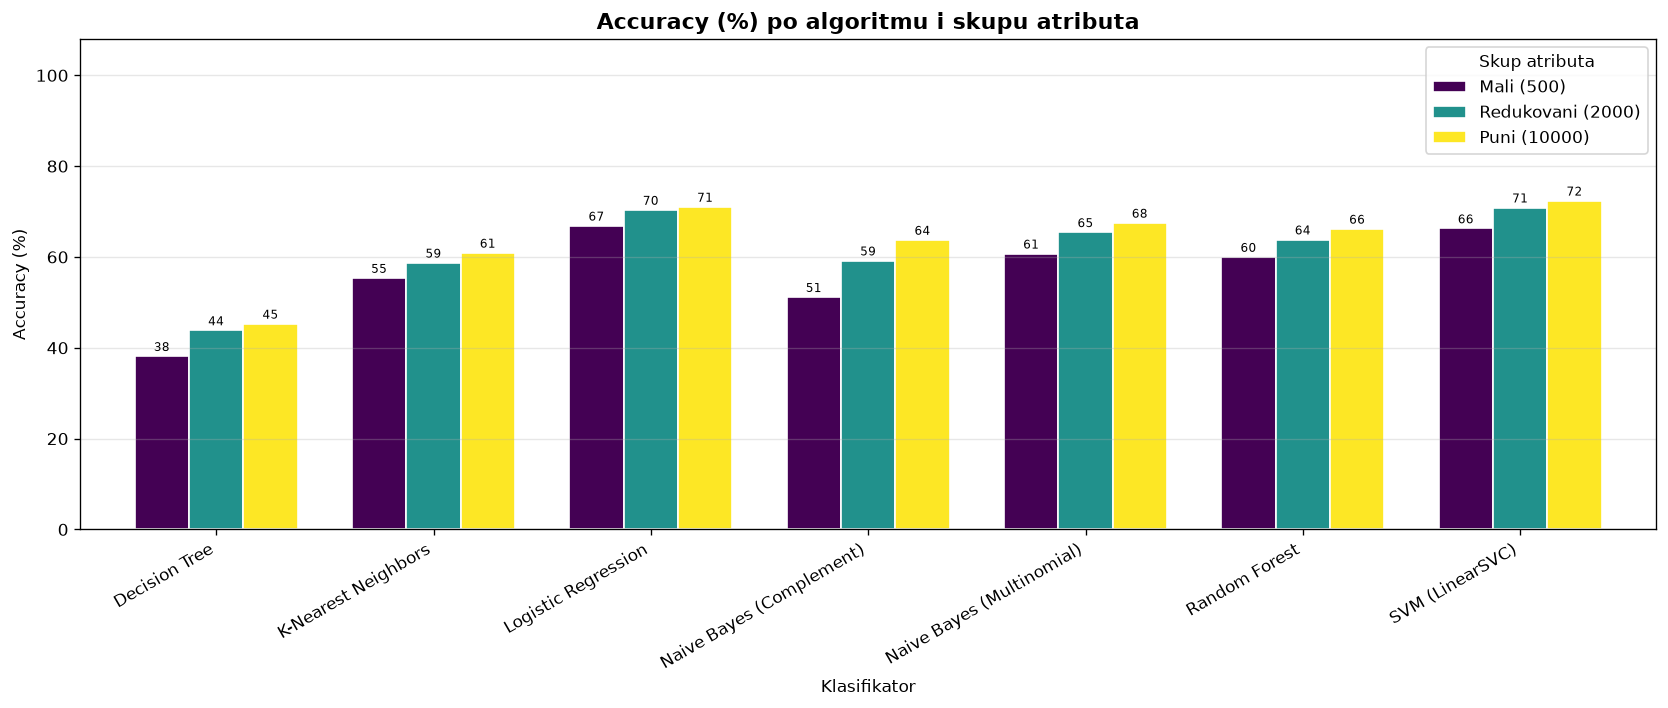

Slika sacuvana: 12_accuracy_bar.png


In [7]:
pivot_plot = results_df.pivot(index='Klasifikator', columns='Skup atributa', values='Accuracy')[col_order]

fig, ax = plt.subplots(figsize=(14, 6))
pivot_plot.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='white', width=0.75)
ax.set_title('Accuracy (%) po algoritmu i skupu atributa', fontsize=13, fontweight='bold')
ax.set_xlabel('Klasifikator')
ax.set_ylabel('Accuracy (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Skup atributa')
ax.set_ylim(0, 108)
ax.grid(axis='y', alpha=0.3)
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.0f}', (p.get_x() + p.get_width()/2, h + 0.5),
                    ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(SLIKE_PATH, '12_accuracy_bar.png'))
plt.show()
print('Slika sacuvana: 12_accuracy_bar.png')

> **Zaključak:** Grouped bar chart vizuelno potvrđuje dominaciju SVM i Logističke regresije kroz sve tri konfiguracije atributa. Visina stubova konstantno raste sa leva (Mali 500) ka desno (Puni 10000) za sve algoritme, što potvrđuje pozitivan uticaj povećanja broja atributa. Decision Tree ima najniže stubove i ujedno najveći relativni pad ka manjem broju atributa. Random Forest, uprkos 200 stabala, zaostaje za jednostavnijim linearnim modelima — što je tipično za TF-IDF reprezentacije gde linearna separabilnost klasa dominira.

### Ćelija 7 - Vizualizacija: heatmap metrika za puni skup

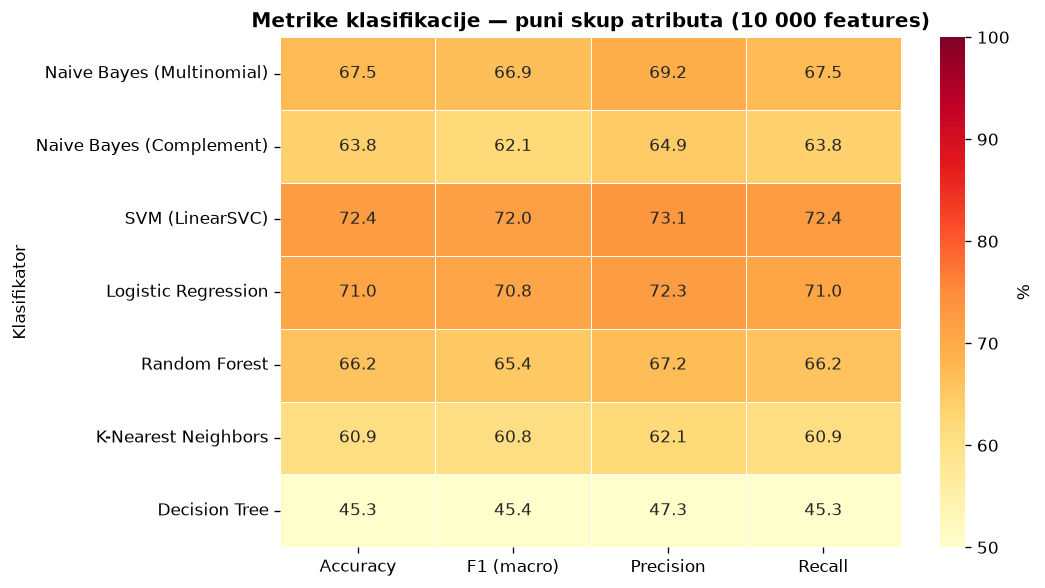

Slika sacuvana: 13_heatmap_metrike.png

                           Accuracy  F1 (macro)  Precision  Recall
Klasifikator                                                      
Naive Bayes (Multinomial)     67.52       66.91      69.18   67.52
Naive Bayes (Complement)      63.76       62.13      64.87   63.76
SVM (LinearSVC)               72.40       72.03      73.06   72.40
Logistic Regression           71.04       70.82      72.31   71.04
Random Forest                 66.20       65.37      67.15   66.20
K-Nearest Neighbors           60.92       60.79      62.11   60.92
Decision Tree                 45.28       45.37      47.34   45.28


In [8]:
full_res = (results_df[results_df['Skup atributa'] == 'Puni (10000)']
            .set_index('Klasifikator')[['Accuracy','F1 (macro)','Precision','Recall']])

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(full_res.astype(float), annot=True, fmt='.1f',
            cmap='YlOrRd', ax=ax, linewidths=0.5, vmin=50, vmax=100,
            cbar_kws={'label': '%'})
ax.set_title('Metrike klasifikacije — puni skup atributa (10 000 features)', fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(os.path.join(SLIKE_PATH, '13_heatmap_metrike.png'))
plt.show()
print('Slika sacuvana: 13_heatmap_metrike.png')
print()
print(full_res.to_string())

> **Zaključak:** Heatmap pokazuje da su sve četiri metrike (Accuracy, F1 macro, Precision, Recall) međusobno konzistentne za svaki algoritam — razlika između njih je manja od 1pp za većinu modela, što potvrđuje da je dataset balansiran (nema dominantnih klasa koje bi narušavale metriku). SVM i LR imaju toplu nijansu (visoke vrednosti) u svim kolonama, dok Decision Tree ima najhladniju nijansu. Mala razlika između Precision i Recall ukazuje na to da modeli ne favorizuju ni preciznost ni odziv — što je poželjno kod balansiranog višeklasnog problema.

### Ćelija 8 - Vizualizacija: efekat broja atributa (linijski grafikon)

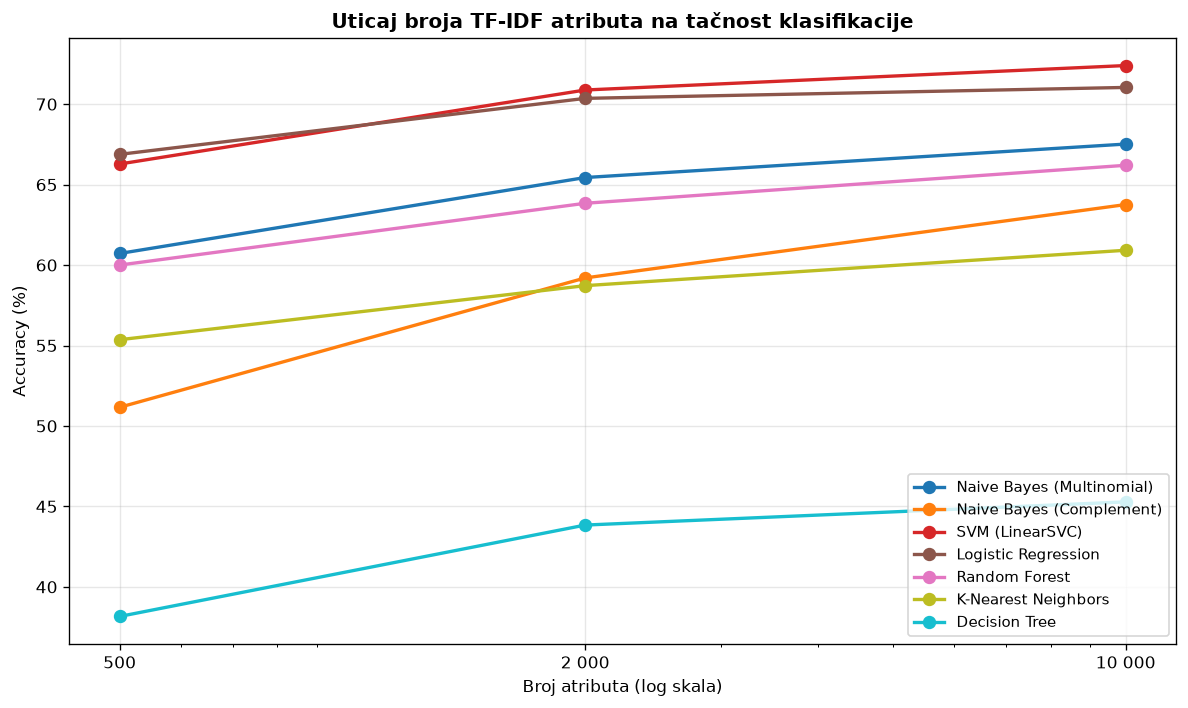

Slika sacuvana: 14_efekat_broja_atributa.png


In [9]:
feat_order = ['Mali (500)', 'Redukovani (2000)', 'Puni (10000)']
feat_sizes = [500, 2000, 10000]
palette    = cm.tab10(np.linspace(0, 1, len(classifiers)))

fig, ax = plt.subplots(figsize=(10, 6))
for idx, clf_name in enumerate(classifiers.keys()):
    sub = results_df[results_df['Klasifikator'] == clf_name].set_index('Skup atributa')
    vals = [sub.loc[f, 'Accuracy'] for f in feat_order]
    ax.plot(feat_sizes, vals, 'o-', label=clf_name, color=palette[idx], linewidth=2, markersize=7)

ax.set_xscale('log')
ax.set_xticks(feat_sizes)
ax.set_xticklabels(['500', '2 000', '10 000'])
ax.set_title('Uticaj broja TF-IDF atributa na tačnost klasifikacije', fontweight='bold')
ax.set_xlabel('Broj atributa (log skala)')
ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SLIKE_PATH, '14_efekat_broja_atributa.png'))
plt.show()
print('Slika sacuvana: 14_efekat_broja_atributa.png')

> **Zaključak:** Linijski grafikon na logaritamskoj skali otkriva da svi algoritmi imaju monotono rastuće krive — svaki dodatni atribut donosi poboljšanje. Najstrmije krive ima Naive Bayes Complement (brzo pada bez atributa) a najravnije Logistička regresija (najefikasnija i pri malom broju atributa). Pređene tačke 500→2000 i 2000→10000 pokazuju da je dobitak od 500 na 2000 veći nego od 2000 na 10000 za većinu modela, što sugeriše da se krive počinju zasićivati — sa još više atributa (npr. 20 000) poboljšanje bi verovatno bilo marginalno.